# Used Car Price Prediction using Artificial Neural Network (TensorFlow)
This notebook builds an ANN model to predict used car prices using TensorFlow.
Steps followed:
1. Read Data
2. Display Data
3. Basic Data Analysis
4. Correlation Analysis
5. Apply Min-Max Scaling
6. Create Neural Network Model
7. Display Model Architecture
8. Display Weight Matrices
9. Train Model with Validation Data
10. Plot Training Loss and Accuracy

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 2. Read Dataset

In [3]:
# Load dataset
df = pd.read_csv("car_data_v2.csv")

df.head()

,car_name,brand,model,vehicle_age,km_driven,mileage,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,19.70,46.30,5,120000
1,Maruti Alto,Maruti,Alto,9,37000,20.92,67.10,5,226000
2,Maruti Wagon R,Maruti,Wagon R,8,35000,18.90,67.10,5,350000
3,Maruti Wagon R,Maruti,Wagon R,3,17512,20.51,67.04,5,410000
4,Hyundai Venue,Hyundai,Venue,2,20000,18.15,118.35,5,1050000


## 3. Display Data and Basic Data Analysis

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119 entries, 0 to 2118
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   car_name       2119 non-null   object 
 1   brand          2119 non-null   object 
 2   model          2119 non-null   object 
 3   vehicle_age    2119 non-null   int64  
 4   km_driven      2119 non-null   int64  
 5   mileage        2119 non-null   float64
 6   max_power      2119 non-null   float64
 7   seats          2119 non-null   int64  
 8   selling_price  2119 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 149.1+ KB


In [5]:
df.shape

(2119, 9)

In [6]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'mileage',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [7]:
df.describe()

,vehicle_age,km_driven,mileage,max_power,seats,selling_price
count,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2.119000e+03
mean,6.153374,42207.621992,22.574856,61.802931,5.002832,3.287744e+05
std,3.524845,27950.561196,3.008683,13.112960,0.176503,1.496699e+05
min,0.000000,581.000000,14.400000,38.400000,4.000000,4.000000e+04
25%,4.000000,21000.000000,20.510000,53.260000,5.000000,2.490000e+05
50%,5.000000,38000.000000,22.740000,67.000000,5.000000,3.150000e+05
75%,8.000000,58494.000000,23.950000,67.050000,5.000000,3.900000e+05
max,29.000000,425785.000000,33.540000,123.370000,7.000000,1.240000e+06


## 4. Correlation Analysis

In [8]:
# multi variate analysis
cor_matrix=df.corr(numeric_only=True)
cor_matrix

,vehicle_age,km_driven,mileage,max_power,seats,selling_price
vehicle_age,1.000000,0.518790,-0.335906,-0.247142,-0.056857,-0.651667
km_driven,0.518790,1.000000,-0.054041,-0.154716,-0.068281,-0.398813
mileage,-0.335906,-0.054041,1.000000,-0.289371,-0.224627,-0.014413
max_power,-0.247142,-0.154716,-0.289371,1.000000,0.112602,0.718961
seats,-0.056857,-0.068281,-0.224627,0.112602,1.000000,0.146811
selling_price,-0.651667,-0.398813,-0.014413,0.718961,0.146811,1.000000


<Axes: >

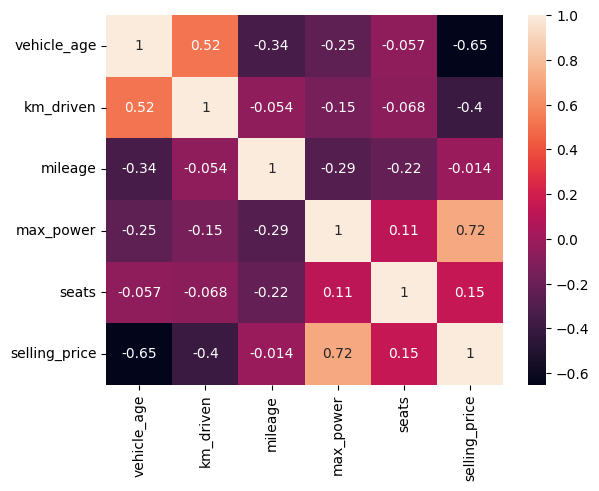

In [9]:
sns.heatmap(data=cor_matrix,annot=True)

In [10]:
df.drop(columns=['car_name', 'brand', 'model','mileage','seats'],axis=1,inplace=True)

In [ ]:
df.head()

## 5. Feature Scaling using Min-Max Scaler

In [12]:
# Separate features and target
X = df.drop('selling_price', axis=1)

In [13]:
X

,vehicle_age,km_driven,max_power
0,9,120000,46.30
1,9,37000,67.10
2,8,35000,67.10
3,3,17512,67.04
4,2,20000,118.35
...,...,...,...
2114,6,60000,67.04
2115,7,44000,47.30
2116,4,29847,67.00
2117,4,12706,47.30


In [14]:
y = df['selling_price']
y

0        120000
1        226000
2        350000
3        410000
4       1050000
         ...   
2114     385000
2115     275000
2116     485000
2117     313000
2118     395000
Name: selling_price, Length: 2119, dtype: int64

In [15]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [16]:
X_train

,vehicle_age,km_driven,max_power
1036,13,110000,46.30
764,2,20387,47.30
668,10,50000,67.10
1502,11,73000,58.16
926,3,30000,67.04
...,...,...,...
1638,6,51127,67.04
1095,21,80000,67.10
1130,16,40000,67.10
1294,2,40000,47.30


In [17]:
X_train.shape

(1695, 3)

In [18]:
X_train.shape[1]

3

In [19]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

In [ ]:
X_train

In [ ]:
X_test

In [21]:
from sklearn.preprocessing import MinMaxScaler
y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test = y_scaler.transform(y_test.values.reshape(-1,1))

## 6. Create Artificial Neural Network Model

In [22]:
hidden_layer_1=layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],))

c:\Users\nilay\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
hidden_layer_2=layers.Dense(16, activation='relu')

In [24]:
output_layer=layers.Dense(1)

In [25]:
model = keras.Sequential([    
    hidden_layer_1,
    hidden_layer_2,
    output_layer
])


"""model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])"""

"model = keras.Sequential([\n    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),\n    layers.Dense(16, activation='relu'),\n    layers.Dense(1)\n])"

## 7. Display Model Architecture

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673 (2.63 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Display Weight Matrices and Their Dimensions

In [159]:
model.layers

[<Dense name=dense_15, built=True>,
 <Dense name=dense_16, built=True>,
 <Dense name=dense_17, built=True>]

In [160]:
model.layers[0]

<Dense name=dense_15, built=True>

In [161]:
model.layers[0].get_weights()

[array([[-0.4000417 , -0.2765013 ,  0.22294256, -0.39116666, -0.02405182,
          0.01370832, -0.40703267, -0.2742337 ,  0.02759352,  0.08564702,
          0.21423581,  0.23783997, -0.11409393,  0.16067776, -0.10291666,
          0.40329793,  0.39942363, -0.32062033,  0.04614261,  0.0252682 ,
         -0.32845718, -0.21252222, -0.3681165 , -0.14729768, -0.18498547,
          0.39921823,  0.39599344, -0.08150682,  0.14494327, -0.36228472,
          0.29602042, -0.3647908 ],
        [ 0.12440613, -0.09141955, -0.2566709 , -0.18795955, -0.12950456,
         -0.4063953 ,  0.15153435, -0.16712345,  0.0026198 , -0.21942692,
          0.08512631,  0.1983985 ,  0.35694465,  0.07667592,  0.19500718,
         -0.22158709,  0.29490665, -0.16146177, -0.22844885, -0.11012864,
         -0.38944417,  0.09990504,  0.03776291,  0.09896007, -0.25221705,
          0.16657856,  0.25888774, -0.08740857, -0.3717181 ,  0.17229572,
          0.34733686,  0.4018707 ],
        [-0.236079  ,  0.37891123,  0.02

In [162]:
model.layers[0].get_weights()[0].shape

(3, 32)

In [163]:
model.layers[1].get_weights()[0].shape

(32, 16)

In [164]:
model.layers[2].get_weights()[0].shape

(16, 1)

In [165]:
for layer in model.layers:
    weights = layer.get_weights()
    if weights:
        print("Layer:", layer.name)
        print("Weight Matrix Shape:", weights[0].shape)
        print("Bias Shape:", weights[1].shape)
        print()

Layer: dense_15
Weight Matrix Shape: (3, 32)
Bias Shape: (32,)

Layer: dense_16
Weight Matrix Shape: (32, 16)
Bias Shape: (16,)

Layer: dense_17
Weight Matrix Shape: (16, 1)
Bias Shape: (1,)



## 9. Compile and Train Model

| Component    | Purpose                                |
| ------------ | -------------------------------------- |
| Loss (MSE)   | Used by the model to learn             |
| Metric (RMSE) | Used by humans to evaluate performance |

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

Epoch is one complete pass of the entire training dataset through the neural network during training.

Simple Explanation

When training a model, the algorithm learns by repeatedly seeing the data.
Each time the model processes all training samples once, it is called one epoch.

Example

Suppose your dataset has 1000 training samples.

Epoch 1 → model sees all 1000 samples once
Epoch 2 → model sees all 1000 samples again
Epoch 10 → dataset has been used 10 times for learning
Important Note

During each epoch, the model:

Makes predictions
Calculates the loss (error)
Updates weights using the optimizer

One-line Definition 
Epoch = One full iteration over the entire training dataset during model training.

In [167]:
#mini-batch
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,   # mini batch
    validation_data=(X_test, y_test)
)

Epoch 1/5


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0976 - mae: 0.2621 - val_loss: 0.0647 - val_mae: 0.2100
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0645 - mae: 0.1989 - val_loss: 0.0449 - val_mae: 0.1645
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0494 - mae: 0.1581 - val_loss: 0.0343 - val_mae: 0.1374
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0442 - mae: 0.1403 - val_loss: 0.0286 - val_mae: 0.1219
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0405 - mae: 0.1275 - val_loss: 0.0253 - val_mae: 0.1130


In [168]:
#SGD
"""history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=1,     # one sample at a time
    validation_data=(X_test, y_test)
)"""

'history = model.fit(\n    X_train,\n    y_train,\n    epochs=50,\n    batch_size=1,     # one sample at a time\n    validation_data=(X_test, y_test)\n)'

In [169]:
#Batch Gradient Descent
"""history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=len(X_train),
    validation_data=(X_test, y_test)
)"""

'history = model.fit(\n    X_train,\n    y_train,\n    epochs=50,\n    batch_size=len(X_train),\n    validation_data=(X_test, y_test)\n)'

## 10. Plot Training Loss and Accuracy

In [170]:
history.history

{'loss': [0.0906854122877121,
  0.06261517852544785,
  0.04736608266830444,
  0.03912564739584923,
  0.034454070031642914],
 'mae': [0.24897751212120056,
  0.19060161709785461,
  0.15398573875427246,
  0.13234175741672516,
  0.12112041562795639],
 'val_loss': [0.06472987681627274,
  0.0448618158698082,
  0.03430510684847832,
  0.0285648126155138,
  0.025313938036561012],
 'val_mae': [0.20996610820293427,
  0.16445204615592957,
  0.13740594685077667,
  0.12192428112030029,
  0.1129959374666214]}

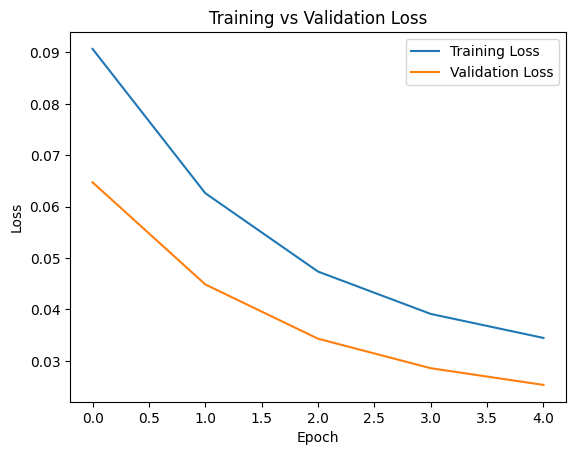

In [171]:
plt.figure()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

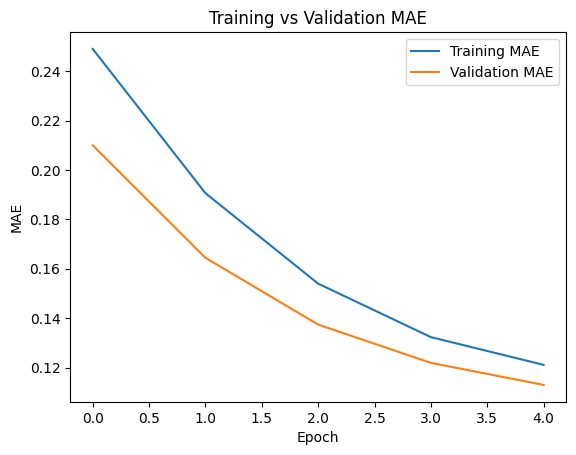

In [172]:
plt.figure()

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

In [173]:
y_pred_scaled = model.predict(X_test)
y_pred_scaled[0:5]

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  


array([[0.14907554],
       [0.14192575],
       [0.1782979 ],
       [0.1653504 ],
       [0.1770051 ]], dtype=float32)

In [175]:
y_pred_actual = y_scaler.inverse_transform(y_pred_scaled)
y_pred_actual[0:5]

array([[217399.89],
       [208891.64],
       [252174.5 ],
       [236766.98],
       [250636.06]], dtype=float32)